In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np
from PIL import Image, ImageDraw  # type: ignore
import torch

from thin_plate_spline import ThinPlateSpline

In [2]:
def increase_ctrl_points():
    """Generate ctrl points that increase the center of the image

    (In proportion of the desired shapes)
    """
    input_ctrl = torch.tensor(
        [
            [0.25, 0.25],  # (i_0, j_0)
            [0.25, 0.75],  # (i_0, j_1)
            [0.75, 0.25],  # (i_1, j_0)
            [0.75, 0.75],  # (i_1, j_1)
        ]
    )

    output_ctrl = torch.tensor(
        [
            [0.15, 0.15],
            [0.15, 0.85],
            [0.85, 0.15],
            [0.85, 0.85],
        ]
    )

    corners = torch.tensor(  # Add corners ctrl points
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
            [1.0, 1.0],
        ]
    )
    # return input_ctrl, output_ctrl
    return torch.cat((input_ctrl, corners)), torch.cat((output_ctrl, corners))


def decrease_ctrl_points():
    """Generate ctrl points that decrease the center of the image

    (In proportion of the desired shapes)
    """
    input_ctrl = torch.tensor(
        [
            [0.25, 0.25],  # (i_0, j_0)
            [0.25, 0.75],  # (i_0, j_1)
            [0.75, 0.25],  # (i_1, j_0)
            [0.75, 0.75],  # (i_1, j_1)
        ]
    )

    output_ctrl = torch.tensor(
        [
            [0.35, 0.35],
            [0.35, 0.65],
            [0.65, 0.35],
            [0.65, 0.65],
        ]
    )

    corners = torch.tensor(  # Add corners ctrl points
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
            [1.0, 1.0],
        ]
    )

    return torch.cat((input_ctrl, corners)), torch.cat((output_ctrl, corners))


def random_ctrl_points():
    """Generate random ctrl points

    (In proportion of the desired shapes)
    """
    torch.manual_seed(777)
    input_ctrl = torch.rand(10, 2)
    output_ctrl = input_ctrl + torch.randn(10, 2) * 0.05

    corners = torch.tensor(  # Add corners ctrl points
        [
            [0.0, 0.0],
            [1.0, 0.0],
            [0.0, 1.0],
            [1.0, 1.0],
        ]
    )

    return torch.cat((input_ctrl, corners)), torch.cat((output_ctrl, corners))



torch.Size([1000, 1000, 2])
torch.Size([1000, 1000, 2])


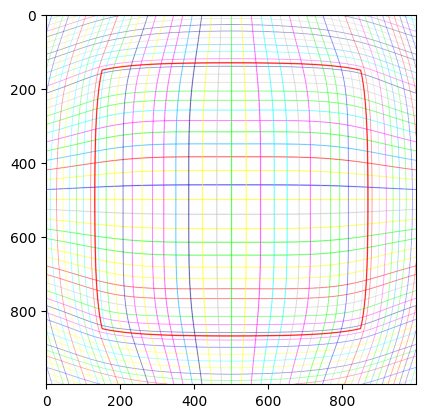

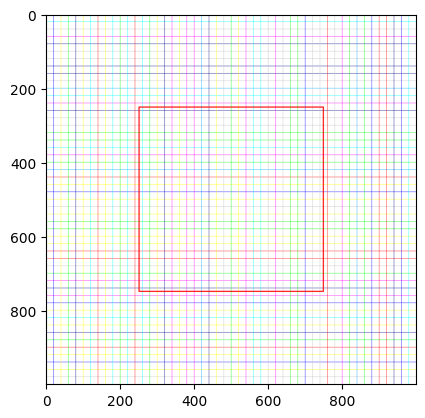

In [5]:
def main():
    """Warp an image"""

    # Load the image and draw a rectangle in the middle
    image = Image.open("images/test_img_grid.png")
    width, height = image.size
    ImageDraw.Draw(image).rectangle([width * 0.25, height * 0.25, width * 0.75, height * 0.75],width=3,outline=(255,0,0))

    size = torch.tensor((height, width))

    # Build control points
    input_ctrl, output_ctrl = increase_ctrl_points()
    # input_ctrl, output_ctrl = decrease_ctrl_points()
    # input_ctrl, output_ctrl = random_ctrl_points()  # input_ctrl.shape=[14,2], output_ctrl.shape=[14,2]
    input_ctrl *= size
    output_ctrl *= size

    # Fit the thin plate spline from output to input
    tps = ThinPlateSpline(1/14)
    tps.fit(output_ctrl,input_ctrl)

    # Create the 2d meshgrid of indices for output image
    i = torch.arange(height, dtype=torch.float32)
    j = torch.arange(width, dtype=torch.float32)

    ii, jj = torch.meshgrid(i, j, indexing="ij")
    output_indices = torch.cat((ii[..., None], jj[..., None]), dim=-1)  # Shape (H, W, 2)
    print(output_indices.shape)

    # Transform it into the input indices
    input_indices = tps.transform(output_indices.reshape(-1, 2)).reshape(height, width, 2)
    print(input_indices.shape)

    # Interpolate the resulting image
    grid = 2 * input_indices / size - 1  # Into [-1, 1]
    grid = torch.flip(grid, (-1,))  # Grid sample works with x,y coordinates, not i, j
    torch_image = torch.tensor(np.array(image), dtype=torch.float32).permute(2, 0, 1)[None, ...]  # .shape=[1,3,h=259,w=194]
    warped = torch.nn.functional.grid_sample(torch_image, grid[None, ...], align_corners=False)[0] # grid[None, ...].shape = torch.Size([1, 259, 194, 2])
                                                                                                # warped.shape = torch.Size([3, 259, 194])
    plt.figure()
    plt.imshow(warped.permute(1, 2, 0).to(torch.uint8))

    plt.figure()
    plt.imshow(image)

    plt.show()
main()